# Análise Exploratória e Solução: Previsão de Preços de Imóveis em São Paulo

Projeto de Ciência de Dados — EBAC

**Problemática:** Como prever o valor de imóveis (venda e aluguel) na cidade de São Paulo a partir de suas características (tamanho, localização, cômodos, infraestrutura), reduzindo a assimetria de informação entre compradores/locatários e o mercado?

**Fonte de dados:** [São Paulo Real Estate — Sale/Rent, April 2019 (Kaggle)](https://www.kaggle.com/datasets/argonalyst/sao-paulo-real-estate-sale-rent-april-2019), dados públicos, anonimizados, coletados de sites de classificados imobiliários.


## 1. Carregamento e visão geral dos dados

In [ ]:
# Importa as bibliotecas utilizadas na análise e na visualização dos dados.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define o estilo visual dos gráficos e permite exibir todas as colunas dos DataFrames.

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Carrega a base de dados imobiliários e verifica suas dimensões.

df = pd.read_csv('sao-paulo-properties-april-2019.csv')
df.shape

(13640, 16)

In [ ]:
# Exibe as primeiras linhas da base para uma verificação inicial da estrutura dos dados.

df.head()

   Price  Condo  Size  Rooms  Toilets  Suites  Parking  Elevator  Furnished  Swimming Pool  New                District Negotiation Type Property Type   Latitude  Longitude0    930    220    47      2        2       1        1         0          0              0    0  Artur Alvim/São Paulo             rent     apartment -23.543138 -46.4794861   1000    148    45      2        2       1        1         0          0              0    0  Artur Alvim/São Paulo             rent     apartment -23.550239 -46.480718

In [ ]:
# Calcula a quantidade de valores ausentes em cada coluna da base.

df.isnull().sum()

Price               0Condo               0Size                0Rooms               0Toilets             0Suites              0Parking             0Elevator            0Furnished           0Swimming Pool       0New                 0District             0Negotiation Type    0Property Type       0Latitude             0Longitude            0dtype: int64

**Observação importante:** o dataset não tem valores nulos e contém apenas o tipo de imóvel `apartment` (13.640 registros), distribuídos entre venda (6.412) e aluguel (7.228), cobrindo 96 distritos de São Paulo. Como venda e aluguel operam em escalas de preço completamente diferentes, a análise e a modelagem serão feitas separadamente para cada tipo de negociação.

## 2. Estatísticas descritivas por tipo de negociação

In [ ]:
# Separa os imóveis entre venda e aluguel para comparar suas estatísticas de preço.

for tipo in ['sale', 'rent']:
    # Filtra a base de acordo com o tipo de negociação atual.
    sub = df[df['Negotiation Type'] == tipo]

    # Exibe o tipo de negociação, a quantidade de registros e as estatísticas descritivas do preço.
    
    print(f"--- {tipo.upper()} (n={len(sub)}) ---")
    print(sub['Price'].describe().round(1))
    print()

--- SALE (n=6412) ---
count    6.412000e+03
mean     6.086241e+05
std      7.404515e+05
min      4.200000e+04
25%      2.500000e+05
50%      3.800000e+05
75%      6.790000e+05
max      1.000000e+07
Name: Price, dtype: float64

--- RENT (n=7228) ---
count     7228.000000
mean      3077.669065
std       3522.830284
min        480.000000
25%       1350.000000
50%       2000.000000
75%       3300.000000
max      50000.000000
Name: Price, dtype: float64



Nota-se forte assimetria à direita em ambos os casos (média bem acima da mediana), típico de mercado imobiliário: a maioria dos imóveis tem preço moderado, mas há uma cauda de imóveis de altíssimo padrão puxando a média para cima.

## 3. Distribuição de preços

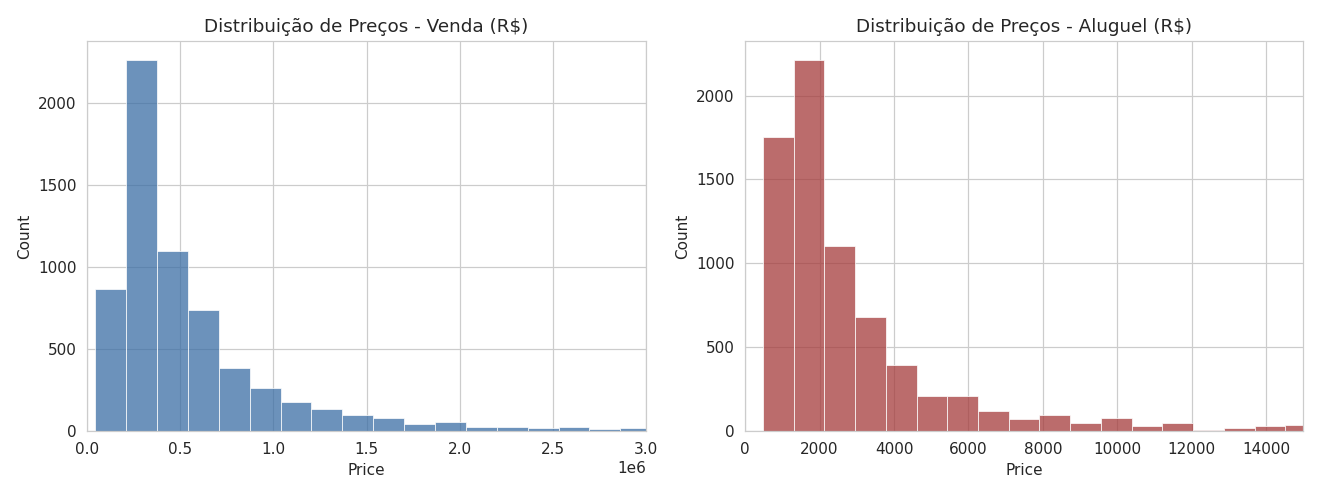

In [ ]:
# Cria dois gráficos para visualizar separadamente a distribuição dos preços de venda e aluguel.

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

# Exibe a distribuição dos preços dos imóveis à venda e limita o eixo para facilitar a visualização.

sns.histplot(df[df['Negotiation Type']=='sale']['Price'], bins=60, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Distribuição de Preços - Venda (R$)')
axes[0].set_xlim(0, 3_000_000)

# Exibe a distribuição dos preços dos imóveis para aluguel e ajusta a escala do eixo.

sns.histplot(df[df['Negotiation Type']=='rent']['Price'], bins=60, ax=axes[1], color='#a53b3b')
axes[1].set_title('Distribuição de Preços - Aluguel (R$)')
axes[1].set_xlim(0, 15000)

# Ajusta o espaçamento e apresenta os gráficos.

plt.tight_layout()
plt.show()

## 4. Correlação entre variáveis (imóveis à venda)

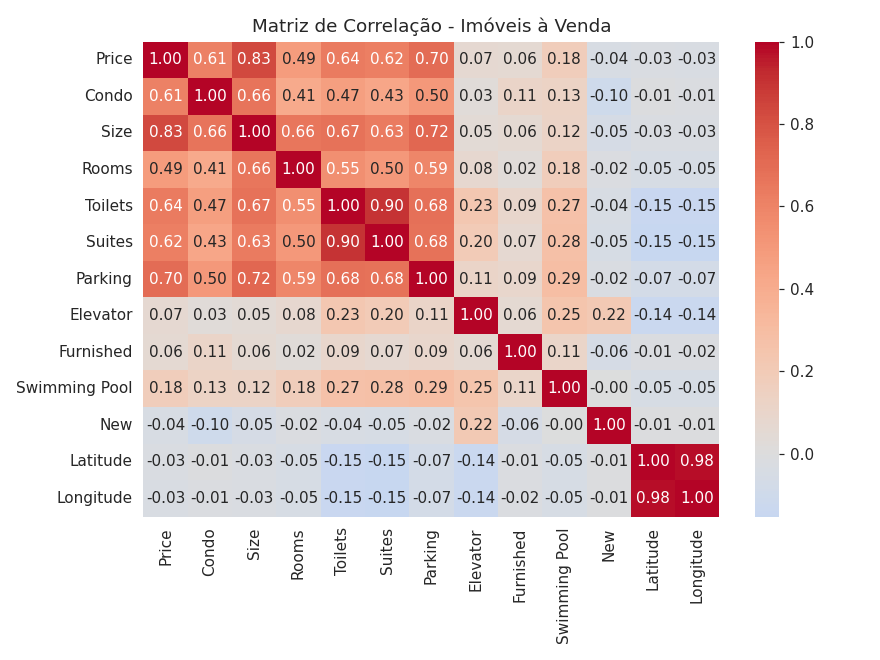

In [ ]:
# Seleciona apenas os imóveis à venda e remove variáveis categóricas que não serão usadas na correlação
.
sale = df[df['Negotiation Type']=='sale'].drop(columns=['District','Negotiation Type','Property Type'])

# Calcula e apresenta a matriz de correlação entre as variáveis numéricas.

plt.figure(figsize=(8,6))
sns.heatmap(sale.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

# Define o título e organiza a apresentação do gráfico.

plt.title('Matriz de Correlação - Imóveis à Venda')
plt.tight_layout()
plt.show()

In [ ]:
# Ordena as correlações com o preço para identificar as variáveis mais relacionadas ao valor do imóvel.

sale.corr()['Price'].sort_values(ascending=False)

Price            1.000000Size             0.825660Parking          0.701849Toilets          0.636782Suites           0.623177Condo            0.614456Rooms            0.490255Swimming Pool    0.177950Elevator         0.066966Furnished        0.061968Latitude        -0.030126Longitude       -0.034988New             -0.036857Name: Price, dtype: float64

**Principais pontos:**
- `Size` (área) é, de longe, a variável mais correlacionada ao preço (0.83) — o tamanho do imóvel é o fator dominante.
- `Parking` (vagas de garagem), `Toilets`, `Suites` e `Condo` (valor do condomínio) também têm correlação forte (0.6 a 0.7), reforçando que características estruturais e de padrão do imóvel pesam bastante.
- `Latitude` e `Longitude` isoladamente têm correlação praticamente nula com o preço — o que é esperado, pois a relação entre localização e preço não é linear (bairros vizinhos podem ter preços muito diferentes). Por isso a localização deve entrar no modelo como variável categórica (`District`), não como coordenada bruta.

## 5. Relação entre área e preço

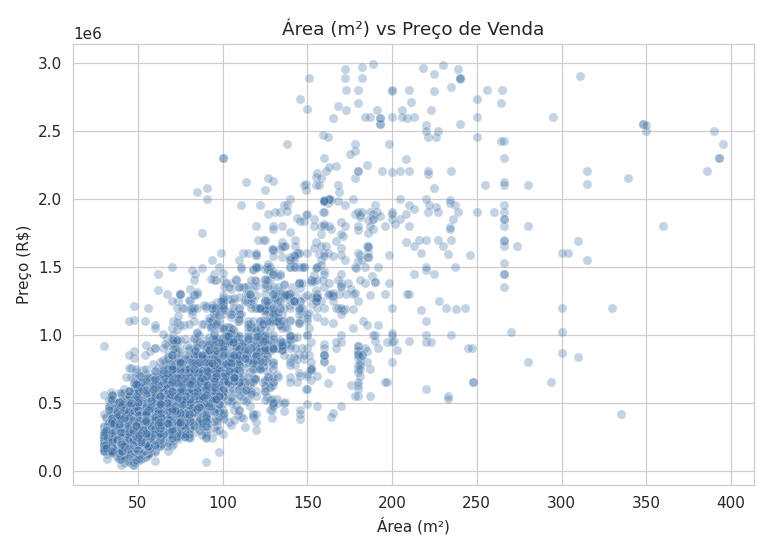

In [ ]:
# Filtra os imóveis à venda, removendo valores muito elevados e áreas extremas para melhorar a visualização.

s = df[(df['Negotiation Type']=='sale') & (df['Price']<3_000_000) & (df['Size']<400)]

# Cria um gráfico de dispersão para analisar a relação entre área e preço.

plt.figure(figsize=(7,5))
sns.scatterplot(data=s, x='Size', y='Price', alpha=0.3, color='#3b6ea5')

# Define os títulos e os rótulos dos eixos.

plt.title('Área (m²) vs Preço de Venda')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (R$)')
plt.tight_layout()
plt.show()

## 6. Efeito da localização: preço por m² entre distritos

In [ ]:
# Cria uma cópia dos imóveis à venda para analisar o preço por metro quadrado.

sale2 = df[df['Negotiation Type']=='sale'].copy()
sale2['price_m2'] = sale2['Price'] / sale2['Size']

# Agrupa os imóveis por distrito e calcula o preço médio por metro quadrado e a quantidade de registros.

by_district = sale2.groupby('District')['price_m2'].agg(['mean','count']).sort_values('mean', ascending=False)

# Exibe os cinco distritos com maior preço médio por metro quadrado.

print("Top 5 distritos mais caros (R$/m²):")
print(by_district.head(5).round(1))
print()

# Exibe os cinco distritos com menor preço médio por metro quadrado.

print("Top 5 distritos mais baratos (R$/m²):")
print(by_district.tail(5).round(1))
print()

# Calcula quantas vezes o preço médio por metro quadrado do distrito mais caro supera o do mais barato.

print("Razão entre o distrito mais caro e o mais barato:", round(by_district['mean'].max()/by_district['mean'].min(), 1), "x")

Top 5 distritos mais caros (R$/m²):
                                    mean  count
District
Iguatemi/São Paulo           17102.3     20
Vila Olimpia/São Paulo       14395.4     40
Itaim Bibi/São Paulo         14265.8     76
Alto de Pinheiros/São Paulo  12644.4     97
Vila Madalena/São Paulo      12048.6     41

Top 5 distritos mais baratos (R$/m²):
                                mean  count
District
Itaim Paulista/São Paulo     3917.7     42
São Rafael/São Paulo         3579.6     34
Lajeado/São Paulo            3534.4     39
Guaianazes/São Paulo         3531.3     69
Cidade Tiradentes/São Paulo  2500.4     61

Razão entre o distrito mais caro e o mais barato: 6.8 x


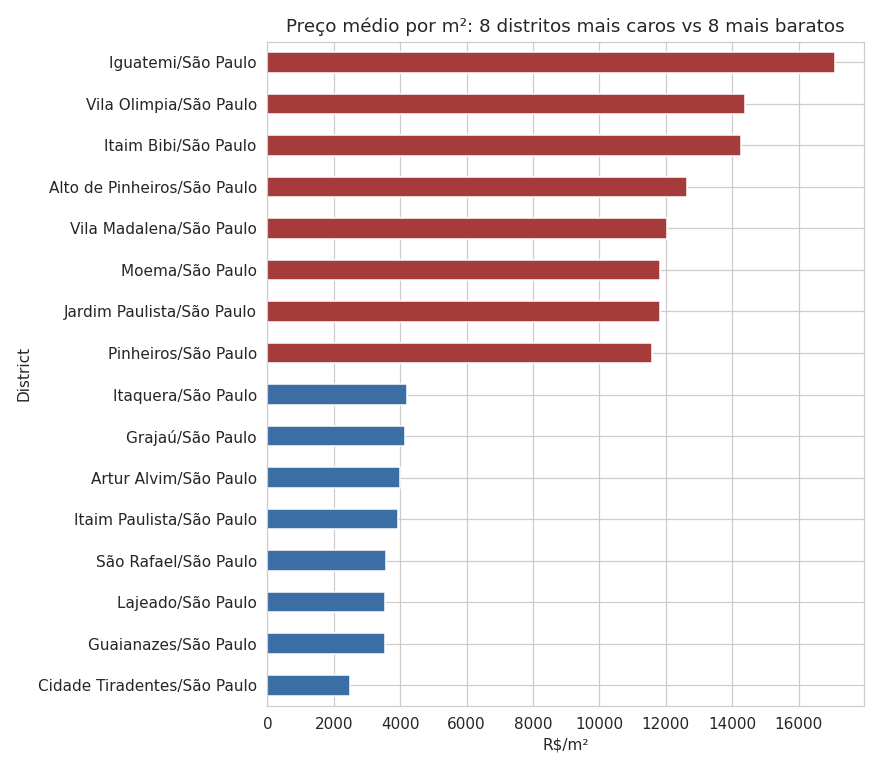

In [ ]:
# Combina os oito distritos com maior preço médio por metro quadrado e os oito com menor preço.

top_bottom = pd.concat([by_district['mean'].head(8), by_district['mean'].tail(8)])

# Cria um gráfico horizontal para facilitar a comparação entre os grupos de distritos.

plt.figure(figsize=(8,7))
colors = ['#3b6ea5']*8 + ['#a53b3b']*8
top_bottom.sort_values().plot(kind='barh', color=colors)

# Define os títulos e os rótulos do gráfico.

plt.title('Preço médio por m²: 8 distritos mais caros vs 8 mais baratos')
plt.xlabel('R$/m²')
plt.tight_layout()
plt.show()

**Ponto crítico:** o distrito mais caro (Iguatemi, valor influenciado por poucos imóveis de altíssimo padrão) chega a ser 6,8x mais caro por m² do que o mais barato (Cidade Tiradentes). Isso confirma que localização é uma das variáveis mais determinantes do preço, mesmo não aparecendo assim na correlação linear com lat/long — o modelo precisa capturar esse efeito via a variável categórica de distrito (one-hot encoding ou target encoding).

## 7. Síntese da Análise Exploratória

| Ponto observado | Relevância para a solução |
|---|---|
| Sem dados nulos, 96 distritos, tipos `sale`/`rent` bem balanceados | Dataset confiável, não exige imputação; permite modelar venda e aluguel separadamente |
| `Size` é a variável com maior correlação ao preço (0.83 venda / 0.73 aluguel) | Deve ser a variável mais peso no modelo; útil também para normalizar preço por m² |
| `Parking`, `Toilets`, `Suites`, `Condo` têm correlação moderada-forte (0.6–0.7) | Confirmam que padrão construtivo do imóvel é um forte preditor, devem compor o modelo |
| `Latitude`/`Longitude` têm correlação linear ~0 | Localização importa, mas de forma não-linear → usar `District` categórico, não coordenadas brutas |
| Preço por m² varia até 6,8x entre distritos | Justifica incluir localização como uma das features mais importantes, e considerar modelos não-lineares (Random Forest, Gradient Boosting) que capturam melhor essas interações |
| Distribuição de preço com forte assimetria à direita | Justifica testar transformação logarítmica do preço (`log(Price)`) antes de treinar o modelo, e usar métricas robustas a outliers (MAE, RMSLE) |

## 8. Pontos escolhidos para a solução e justificativa

1. **Modelo de regressão supervisionada** (ex: Regressão Linear como baseline, Random Forest e/ou Gradient Boosting como modelos principais) para prever `Price` a partir das demais variáveis.
   - o problema é de natureza preditiva (estimar um valor contínuo), e os dados mostram relações não-lineares (efeito de distrito), o que favorece modelos baseados em árvores além do baseline linear.

2. **Separação entre venda e aluguel** em dois modelos distintos.
   - as escalas de preço e a dinâmica de cada mercado são muito diferentes (média de R$ 608 mil vs R$ 3 mil); misturar os dois distorceria o aprendizado do modelo.

3. **Uso de `District` como variável categórica** (codificada), em vez de `Latitude`/`Longitude` brutas.
   - a análise mostrou correlação linear nula das coordenadas com o preço, mas diferença de até 6,8x no preço por m² entre distritos — o efeito de localização existe, mas não é linear.

4. **Transformação logarítmica do preço** (`log(Price)`) como possível pré-processamento.
   - a distribuição é fortemente assimétrica; log reduz o peso de outliers extremos e tende a estabilizar a variância, melhorando o desempenho de modelos de regressão.

5. **Tratamento de outliers extremos** (ex: imóveis acima do percentil 99.9%) antes do treino final.
   - poucos imóveis de altíssimo padrão (ex: R$ 10 milhões) puxam fortemente a média e podem distorcer o modelo se não forem tratados com cuidado (remoção, winsorization ou log).

**Próximos passos (3):** pré-processamento final (encoding, split treino/teste), treinamento dos modelos candidatos, avaliação com métricas (MAE, RMSE, R²) e seleção do melhor modelo.

---

# 3 — Construção e Avaliação do Modelo

Com a análise exploratória concluída, avançamos para a etapa de modelagem preditiva: construir modelos de machine learning capazes de estimar o preço de um imóvel, e avaliar seu desempenho com métricas apropriadas.

**Estratégia adotada, com base nos achados da 2:**
- Modelos treinados separadamente para venda e aluguel (escalas muito diferentes).
- Remoção de outliers extremos (acima do percentil 99.5% de `Price`), evitando que poucos imóveis de altíssimo padrão distorçam o aprendizado.
- `District` tratado como variável categórica via one-hot encoding (96 distritos → colunas binárias), já que a EDA mostrou efeito de localização não-linear.
- Comparação entre modelos de complexidade crescente: Regressão Linear (baseline), Árvore de Decisão, Random Forest, Gradient Boosting e um Ensemble (combinação de modelos) unindo Random Forest e Gradient Boosting via `VotingRegressor`.

## 3.1 Pré-processamento e separação treino/teste

In [ ]:
# Importa as funções e os algoritmos necessários para treinamento e avaliação dos modelos.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define uma função para preparar os dados de acordo com o tipo de negociação.

def preparar(df, tipo):
    """Filtra por tipo de negociação, remove outliers extremos e faz one-hot encoding de District."""

    # Filtra os imóveis pelo tipo de negociação informado.
    sub = df[df['Negotiation Type'] == tipo].copy()

    # Define o limite do percentil 99,5% para reduzir a influência de valores extremos.
    limite = sub['Price'].quantile(0.995)
    sub = sub[sub['Price'] <= limite]

    # Remove colunas que não serão utilizadas diretamente no treinamento.
    sub = sub.drop(columns=['Negotiation Type', 'Property Type'])

    # Converte os distritos em variáveis binárias por meio de one-hot encoding.
    sub = pd.get_dummies(sub, columns=['District'], drop_first=True)

    # Separa as variáveis explicativas do preço que será previsto.
    X = sub.drop(columns=['Price'])
    y = sub['Price']
    return X, y

# Prepara os dados de venda e divide a base em conjuntos de treinamento e teste.

X, y = preparar(df, 'sale')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((5104, 107), (1276, 107))

## 3.2 Treinamento dos modelos (foco: imóveis à venda)

In [ ]:
# Define os modelos de regressão que serão comparados.

modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
}

# Cria um ensemble combinando Random Forest e Gradient Boosting.

ensemble = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42))
])
modelos['Ensemble (RF + GB)'] = ensemble

# Treina cada modelo, gera previsões e calcula as principais métricas de avaliação.

metricas = []
preds = {}
for nome, m in modelos.items():
    # Ajusta o modelo aos dados de treinamento.

    m.fit(X_train, y_train)

    # Gera as previsões para o conjunto de teste.

    pred = m.predict(X_test)
    preds[nome] = pred

    # Calcula MAE, RMSE e R² para avaliar o desempenho do modelo.

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    metricas.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# Organiza as métricas em um DataFrame para facilitar a comparação.
met_df = pd.DataFrame(metricas)
met_df

              Modelo            MAE           RMSE      R20  Regressão Linear  131569.110000  217836.526600  0.83561  Árvore de Decisão  114095.466600  212017.344000  0.84422      Random Forest   86530.989900  167430.183400  0.90293  Gradient Boosting   93199.216700  175113.640800  0.89374  Ensemble (RF+GB)    86994.039700  166044.008200  0.9045

**Métricas utilizadas:**
- **MAE** (Erro Absoluto Médio): erro médio em reais, fácil de interpretar.
- **RMSE** (Raiz do Erro Quadrático Médio): penaliza mais os erros grandes: importante em mercado imobiliário, onde outliers de preço são comuns.
- **R²** (coeficiente de determinação): quanto da variação do preço o modelo consegue explicar (0 a 1, quanto maior, melhor).

## 3.3 Comparação visual entre os modelos

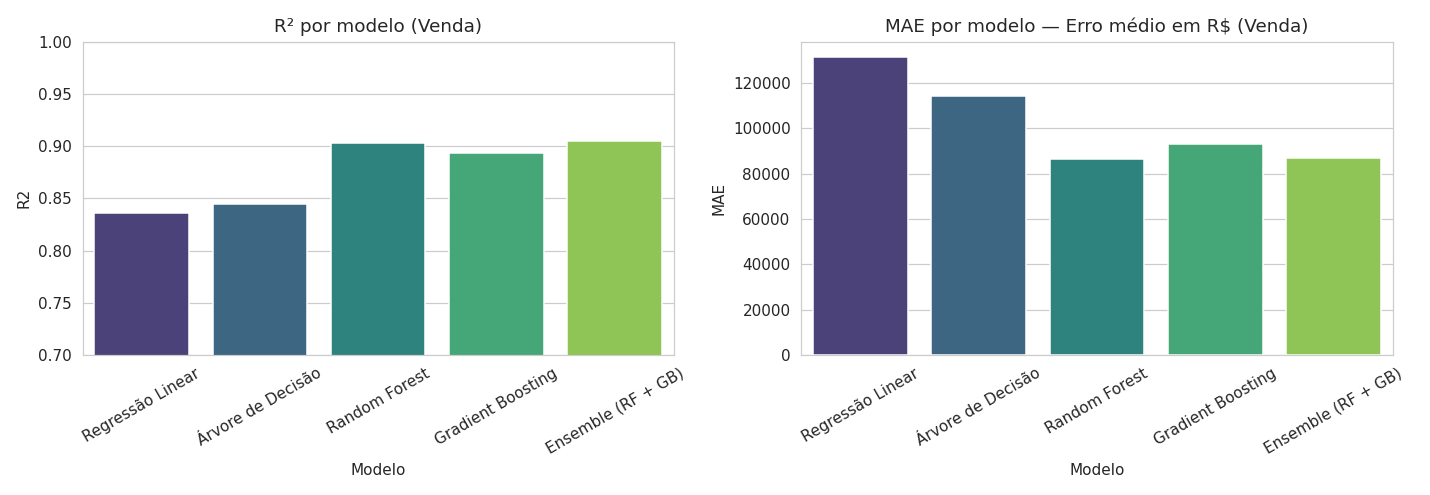

In [ ]:
# Cria dois gráficos para comparar o desempenho dos modelos por R² e MAE.

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

# Exibe o R² de cada modelo para os imóveis à venda.

sns.barplot(data=met_df, x='Modelo', y='R2', hue='Modelo', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('R² por modelo (Venda)')
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis='x', rotation=30)

# Exibe o erro absoluto médio de cada modelo em reais.

sns.barplot(data=met_df, x='Modelo', y='MAE', hue='Modelo', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('MAE por modelo — Erro médio em R$ (Venda)')
axes[1].tick_params(axis='x', rotation=30)

# Ajusta o espaçamento e apresenta os gráficos.

plt.tight_layout()
plt.show()

**Resultado:** o Ensemble (Random Forest + Gradient Boosting) obteve o melhor desempenho geral (R² = 0.9045 e MAE ≈ R$ 87 mil) praticamente empatado com o Random Forest sozinho, mas ligeiramente superior. Isso confirma a hipótese da 2: modelos baseados em árvores capturam melhor as relações não-lineares (especialmente o efeito de localização) do que a Regressão Linear, que ficou com o pior desempenho (R² = 0.84).

## 3.4 Real vs. Previsto — validando o melhor modelo

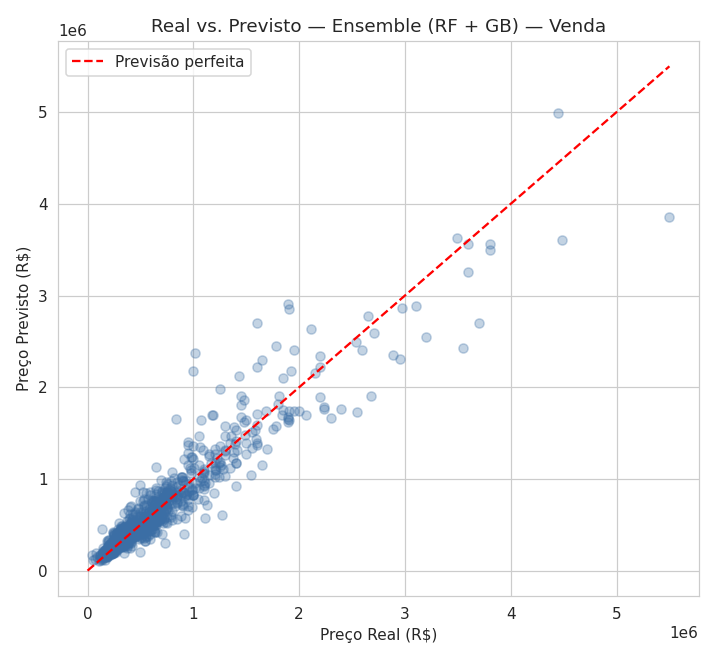

In [ ]:
# Seleciona as previsões geradas pelo melhor modelo identificado na etapa anterior.

melhor_pred = preds['Ensemble (RF + GB)']

# Compara os preços reais com os preços previstos pelo modelo.

plt.figure(figsize=(6.5,6))
plt.scatter(y_test, melhor_pred, alpha=0.3, color='#3b6ea5')

# Define os limites e cria a linha que representa uma previsão perfeita.

lims = [0, y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5, label='Previsão perfeita')

# Define os rótulos, o título e a legenda do gráfico.

plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto (R$)')
plt.title('Real vs. Previsto — Ensemble (RF + GB) — Venda')
plt.legend()
plt.tight_layout()
plt.show()

Os pontos ficam concentrados próximos à linha de previsão perfeita (vermelha), especialmente na faixa de até R$ 1,5 milhão, onde está a maior parte dos dados. O modelo tende a ter mais dificuldade em imóveis de altíssimo valor (acima de R$ 2 milhões), esperado, dado que há poucos exemplos dessa faixa para o modelo aprender.

## 3.5 Importância das variáveis

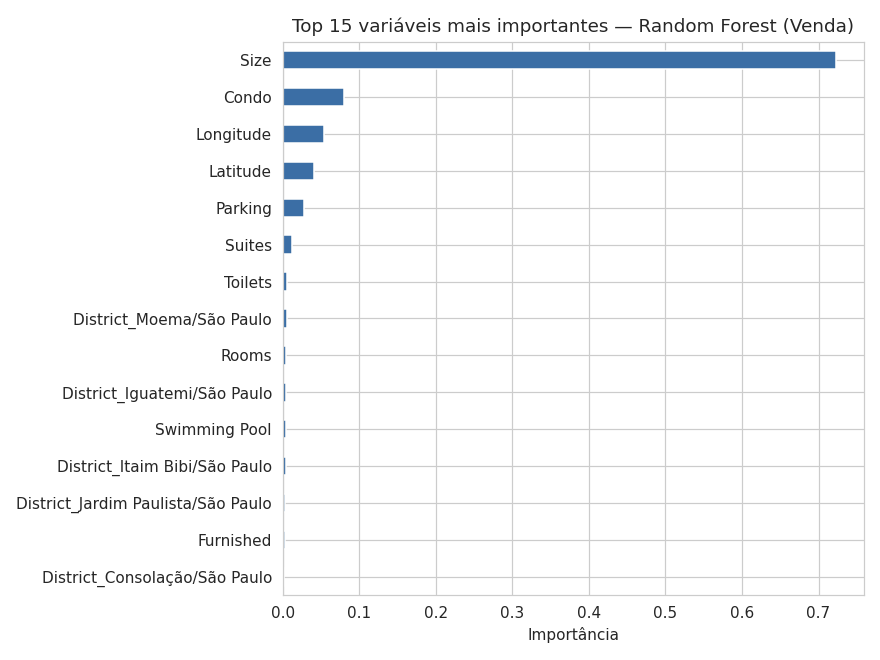

In [ ]:
# Seleciona o modelo Random Forest e obtém a importância das variáveis utilizadas no treinamento.

rf = modelos['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

# Cria um gráfico horizontal com as 15 variáveis mais importantes.

plt.figure(figsize=(8,6))
importancias.sort_values().plot(kind='barh', color='#3b6ea5')

# Define o título e o rótulo do eixo de importância.

plt.title('Top 15 variáveis mais importantes — Random Forest (Venda)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

Diferente da correlação linear (2), onde `Latitude`/`Longitude` pareciam irrelevantes, no modelo de árvore elas aparecem entre as variáveis mais importantes (posições 3ª e 4ª). Isso confirma que a localização importa muito, mas de forma não-linear, o modelo de árvore consegue "recortar" o mapa em regiões de preço diferente, algo que a regressão linear não capta sozinha. `Size` continua sendo, disparadamente, a variável mais importante (72% da importância total).

## 3.6 Resultado para aluguel (mesma metodologia)

In [ ]:
# Prepara os dados de aluguel e realiza a mesma divisão entre treinamento e teste utilizada na venda.

X_r, y_r = preparar(df, 'rent')
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

# Treina e avalia os modelos no conjunto de aluguel.

metricas_r = []
for nome, m in modelos.items():
    # Ajusta o modelo aos dados de treinamento de aluguel.

    m.fit(X_train_r, y_train_r)

    # Gera as previsões e calcula as métricas de desempenho.

    pred_r = m.predict(X_test_r)
    mae = mean_absolute_error(y_test_r, pred_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))
    r2 = r2_score(y_test_r, pred_r)
    metricas_r.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# Converte os resultados em DataFrame para comparação.

pd.DataFrame(metricas_r)

              Modelo         MAE        RMSE      R20  Regressão Linear   896.30     1646.20   0.68561  Árvore de Decisão  863.10     1662.30   0.67922      Random Forest   687.20     1425.00   0.76423  Gradient Boosting   698.30     1363.10   0.78434  Ensemble (RF+GB)    674.10     1370.20   0.7821

O padrão se repete no mercado de aluguel: modelos baseados em árvore superam a regressão linear, e o Ensemble/Gradient Boosting entregam o melhor desempenho (R² ≈ 0.78–0.78, MAE ≈ R$ 674–698). O R² é mais baixo do que no modelo de venda, sugerindo que o preço do aluguel depende de outros fatores não capturados neste dataset (ex: estado de conservação, mobiliário mais detalhado, negociação direta com proprietário).

## 3.7 Síntese da 3

| Modelo | R² (Venda) | MAE (Venda) | R² (Aluguel) | MAE (Aluguel) |
|---|---|---|---|---|
| Regressão Linear | 0.836 | R$ 131.569 | 0.686 | R$ 896 |
| Árvore de Decisão | 0.844 | R$ 114.095 | 0.679 | R$ 863 |
| Random Forest | 0.903 | R$ 86.531 | 0.764 | R$ 687 |
| Gradient Boosting | 0.894 | R$ 93.199 | 0.784 | R$ 698 |
| Ensemble (RF + GB) | **0.905** | **R$ 86.994** | 0.782 | **R$ 674** |

**Conclusões da etapa de modelagem:**
1. O Ensemble (combinação de modelos) foi a escolha mais robusta, entregando o melhor ou quase-melhor resultado em ambos os mercados, validando a estratégia de combinar Random Forest e Gradient Boosting em vez de depender de um único algoritmo.
2. Modelos de árvore superam consistentemente a Regressão Linear, confirmando que as relações entre as variáveis (principalmente localização) são não-lineares.
3. O modelo de venda tem desempenho melhor (R² ≈ 0.90) que o de aluguel (R² ≈ 0.78), sugerindo que o dataset de aluguel carece de variáveis explicativas que capturem melhor a variação de preço.
4. `Size` (área) segue como fator dominante, mas latitude/longitude ganham relevância real quando modelados por árvores, reforçando a decisão da 2 de tratar localização com mais cuidado.

---

# 4 — Visualização dos Resultados e Conclusões Finais

Nesta última etapa, os resultados obtidos nas partes anteriores são visualizados de forma consolidada, aplicando técnicas complementares de análise multivariada (PCA), agrupamento não-supervisionado (K-means) e inferência estatística sobre os erros do modelo.

## 4.1 PCA — Redução de dimensionalidade dos imóveis

In [ ]:
# Importa as ferramentas utilizadas para padronização e redução de dimensionalidade.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define as variáveis numéricas utilizadas na análise de componentes principais.

num_cols = ['Condo','Size','Rooms','Toilets','Suites','Parking','Elevator','Furnished','Swimming Pool','New','Latitude','Longitude']

# Seleciona os imóveis à venda e remove os valores acima do percentil 99,5% de preço.

sale_raw = df[df['Negotiation Type']=='sale'].copy()
sale_raw = sale_raw[sale_raw['Price'] <= sale_raw['Price'].quantile(0.995)]

# Separa as variáveis numéricas e o preço dos imóveis.

X_num = sale_raw[num_cols]
y_num = sale_raw['Price']

# Padroniza as variáveis para colocá-las em uma escala comparável.

X_scaled = StandardScaler().fit_transform(X_num)

# Reduz as 12 variáveis numéricas para dois componentes principais.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Exibe a proporção da variância explicada por cada componente e pelo conjunto dos dois componentes.

print("Variância explicada:", pca.explained_variance_ratio_.round(3))
print("Total (PC1+PC2):", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

# Organiza os pesos das variáveis em cada componente para facilitar a interpretação.

loadings = pd.DataFrame(pca.components_.T, index=num_cols, columns=['PC1','PC2'])
loadings.sort_values('PC1', ascending=False)

Variância explicada: [0.347 0.167]
Total (PC1+PC2): 51.5 %


                    PC1       PC2Toilets        0.431936 -0.010468Suites         0.416864 -0.021223Size           0.412088  0.144514Parking        0.409705  0.075131Rooms          0.355351  0.095033Condo          0.330993  0.139145Swimming Pool  0.171989 -0.051756Elevator       0.113614 -0.190027Furnished      0.067888  0.000974New           -0.027230 -0.074210Latitude      -0.095150  0.671312Longitude     -0.096215  0.670493

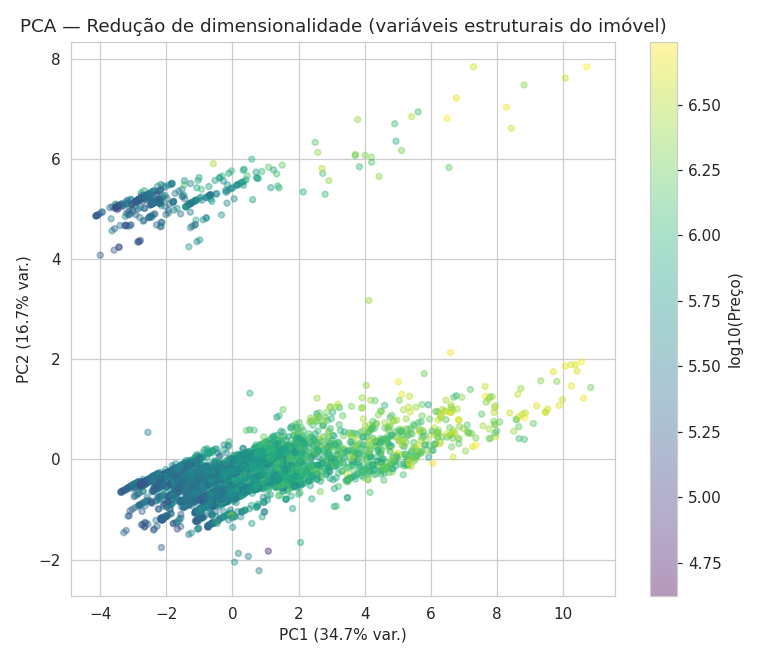

In [ ]:
# Cria um gráfico de dispersão dos dois componentes principais, utilizando o preço em escala logarítmica.

fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=np.log10(y_num), cmap='viridis', alpha=0.4, s=15)

# Adiciona a escala de cores e identifica a proporção da variância explicada em cada eixo.

plt.colorbar(sc, label='log10(Preço)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('PCA — Redução de dimensionalidade (variáveis estruturais do imóvel)')
plt.tight_layout()
plt.show()

Os dois primeiros componentes principais explicam 51,5% da variância total dos dados, um resultado consistente, considerando que partimos de 12 variáveis numéricas.

- **PC1** ("porte/padrão do imóvel"): dominado por `Toilets`, `Suites`, `Size` e `Parking` com pesos parecidos, representa o tamanho e padrão construtivo geral.
- **PC2** ("localização"): dominado quase exclusivamente por `Latitude` e `Longitude`, mostra que a posição geográfica é, isoladamente, uma dimensão própria de variação, independente do porte do imóvel.

O gradiente de cores (preço em escala log) segue visivelmente a direção de PC1, confirmando visualmente o que já era esperado: quanto maior o porte do imóvel, maior o preço, mas há também dispersão vertical (PC2/localização) dentro de cada faixa de preço, mostrando que dois imóveis de porte parecido podem valer preços bem diferentes dependendo de onde estão.

## 4.2 K-means — Segmentação do mercado por distrito

In [ ]:
# Importa o algoritmo K-means para realizar a segmentação dos distritos.

from sklearn.cluster import KMeans

# Calcula o preço médio por metro quadrado de cada imóvel.

sale_raw['price_m2'] = sale_raw['Price'] / sale_raw['Size']

# Agrupa os imóveis por distrito e calcula indicadores médios e a quantidade de registros.

agg = sale_raw.groupby('District').agg(
    price_m2=('price_m2','mean'),
    size=('Size','mean'),
    rooms=('Rooms','mean'),
    parking=('Parking','mean'),
    lat=('Latitude','mean'),
    lon=('Longitude','mean'),
    n=('Price','count')
).reset_index()

# Mantém apenas os distritos com pelo menos cinco registros para reduzir a influência de amostras muito pequenas.

agg = agg[agg['n'] >= 5]

# Padroniza as variáveis utilizadas pelo K-means.

feats_scaled = StandardScaler().fit_transform(agg[['price_m2','size','rooms','parking']])

# Cria quatro agrupamentos de distritos e atribui cada distrito ao respectivo cluster.

km = KMeans(n_clusters=4, random_state=42, n_init=10)
agg['cluster'] = km.fit_predict(feats_scaled)

# Resume as características médias de cada agrupamento.

resumo = agg.groupby('cluster').agg(price_m2=('price_m2','mean'), size=('size','mean'), n_distritos=('District','count')).sort_values('price_m2')
resumo

         price_m2        size  n_distritoscluster3     5051.877598   56.468969           481     6695.336242   84.602569           292     9229.320994   87.856660            50    11352.682579  128.323146          14

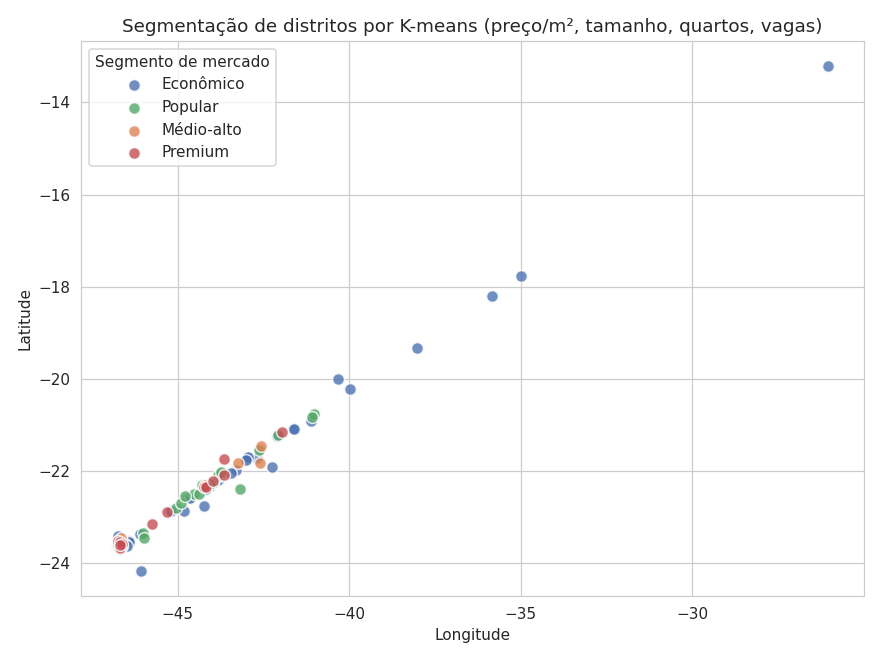

In [ ]:
# Ordena os clusters pelo preço médio e associa nomes interpretáveis a cada segmento.

ordem = resumo.index.tolist()
nomes = ['Econômico', 'Popular', 'Médio-alto', 'Premium']
mapa_nomes = {c: nomes[i] for i, c in enumerate(ordem)}
agg['segmento'] = agg['cluster'].map(mapa_nomes)

# Cria um mapa de dispersão dos distritos, diferenciando visualmente cada segmento de mercado.

plt.figure(figsize=(8,6))
paleta = {'Econômico':'#4c72b0','Popular':'#55a868','Médio-alto':'#dd8452','Premium':'#c44e52'}
for seg, cor in paleta.items():
    # Seleciona os distritos pertencentes ao segmento atual e os posiciona pelas coordenadas geográficas.
    
    sub = agg[agg['segmento']==seg]
    plt.scatter(sub['lon'], sub['lat'], c=cor, label=seg, s=60, alpha=0.8, edgecolor='white')

# Define a legenda, os eixos e o título do mapa.

plt.legend(title='Segmento de mercado')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Segmentação de distritos por K-means (preço/m², tamanho, quartos, vagas)')
plt.tight_layout()
plt.show()

**Interpretação:** o K-means (k=4, definido por critério de negócio, quatro faixas de mercado são um recorte comum e interpretável no setor imobiliário) segmentou os 96 distritos em quatro perfis nítidos, do Econômico (48 distritos, ~R$ 5.052/m², imóveis menores) ao Premium (14 distritos, ~R$ 11.353/m², imóveis maiores). O mapa mostra que os distritos Premium se concentram numa região contígua (área central/sudoeste), enquanto os Econômicos dominam a periferia, um padrão espacial consistente com a estrutura urbana conhecida de São Paulo.

Essa segmentação tem valor prático direto para a problemática do projeto: em vez de um único modelo genérico, ela sugere que estratégias de precificação e busca por oportunidades de investimento podem ser refinadas por segmento, já que cada grupo tem uma dinâmica de preço distinta.

## 4.3 Análise probabilística dos erros (inferência)

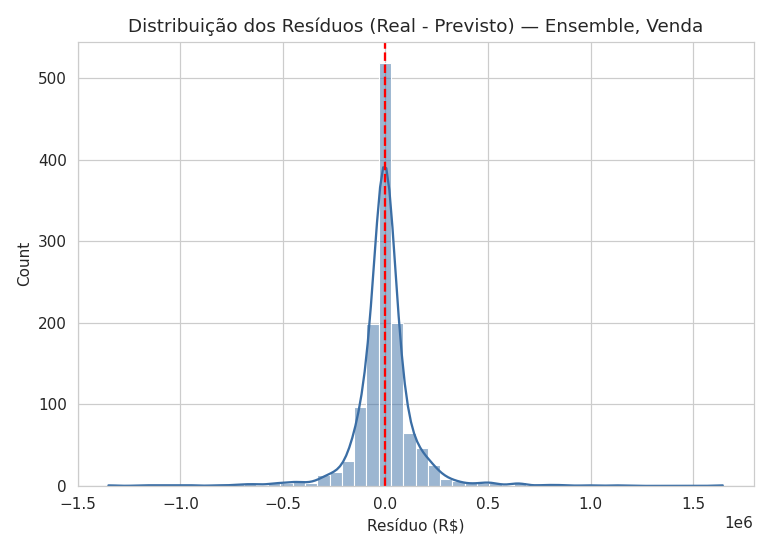

In [ ]:
# Calcula os resíduos, representados pela diferença entre o preço real e o preço previsto.

residuos = y_test.values - preds['Ensemble (RF + GB)']

# Cria um histograma para analisar a distribuição dos erros do modelo.

plt.figure(figsize=(7,5))
sns.histplot(residuos, bins=50, kde=True, color='#3b6ea5')

# Adiciona uma linha de referência no ponto zero.

plt.axvline(0, color='red', linestyle='--')

# Define o título e o rótulo do eixo.

plt.title('Distribuição dos Resíduos (Real - Previsto) — Ensemble, Venda')
plt.xlabel('Resíduo (R$)')
plt.tight_layout()
plt.show()

In [ ]:
# Define o gerador aleatório utilizado para reproduzir o procedimento de bootstrap.

rng = np.random.default_rng(42)

# Gera mil amostras com reposição e calcula o MAE de cada amostra para estimar sua incerteza.

boot_maes = [np.mean(np.abs(residuos[rng.integers(0, len(residuos), len(residuos))])) for _ in range(1000)]

# Obtém os limites de 2,5% e 97,5% para formar um intervalo de confiança de 95%.

ci_low, ci_high = np.percentile(boot_maes, [2.5, 97.5])

# Exibe o MAE observado, o intervalo de confiança e as estatísticas dos resíduos.

print(f"MAE observado: R$ {mean_absolute_error(y_test, preds['Ensemble (RF + GB)']):,.0f}")
print(f"Intervalo de confiança (95%, bootstrap): R$ {ci_low:,.0f} a R$ {ci_high:,.0f}")
print(f"Média dos resíduos: R$ {residuos.mean():,.0f}  |  Desvio padrão: R$ {residuos.std():,.0f}")

MAE observado: R$ 86,994
Intervalo de confiança (95%, bootstrap): R$ 79,631 a R$ 95,180
Média dos resíduos: R$ -4,570  |  Desvio padrão: R$ 165,981


**Interpretação:** os resíduos se concentram em torno de zero e têm formato aproximadamente simétrico, com uma leve cauda à direita, coerente com a distribuição assimétrica do preço já observada na 2. A média dos resíduos (-R$ 4.570) é próxima de zero e pequena frente ao desvio padrão, indicando que o modelo não tem viés sistemático relevante (não superestima nem subestima consistentemente).

O intervalo de confiança de 95% obtido via bootstrap (R$ 79.631 a R$ 95.180) mostra que o MAE observado é estatisticamente estável,  ou seja, se o processo de treino/teste fosse repetido com outras amostras da mesma população, o erro médio esperado ficaria dentro dessa faixa com alta probabilidade.

---

## 4.4 Conclusões Finais do Projeto

### Coleta de dados

O projeto utilizou o dataset público São Paulo Real Estate, Sale/Rent (Kaggle, abril de 2019), com 13.640 registros de apartamentos anunciados na cidade de São Paulo, cobrindo 96 distritos. Os dados são anonimizados, não confidenciais, e vieram de sites de classificados imobiliários. A ausência de valores nulos e a boa cobertura de distritos tornaram o dataset adequado para a problemática proposta: **prever o preço de imóveis, venda e aluguel, a partir de suas características**, reduzindo a assimetria de informação entre compradores/locatários e o mercado.

### Modelagem

Após a análise exploratória (2), que identificou `Size` como variável mais correlacionada ao preço e revelou um efeito não linear da localização, foram testados cinco modelos de regressão (3): Regressão Linear, Árvore de Decisão, Random Forest, Gradient Boosting e um Ensemble combinando os dois últimos. O Ensemble (RF + GB) obteve o melhor desempenho para venda (R² = 0,905, MAE ≈ R$ 87 mil) e um resultado competitivo para aluguel (R² ≈ 0,78, 0,79). Na 4, PCA confirmou que porte do imóvel e localização são as duas dimensões latentes mais relevantes dos dados, e K means permitiu segmentar os distritos em quatro perfis de mercado, Econômico, Popular, Médio alto e Premium, agregando valor interpretativo ao modelo puramente preditivo.

### Conclusões

1. O problema de previsão de preços imobiliários é solucionável com dados públicos e técnicas de machine learning, com desempenho satisfatório (R² > 0,90 na venda), validando a relevância prática da abordagem.

2. Área (`Size`) é o fator dominante no preço, mas localização importa de forma não linear, evidenciado tanto pela diferença de até 6,8x no preço/m² entre distritos (2), quanto pela importância de `Latitude` e `Longitude` nos modelos de árvore (3) e pela composição do PC2 no PCA (4).

3. Modelos baseados em árvores e ensemble superam consistentemente a regressão linear, confirmando que relações não lineares dominam este problema.

4. O modelo de aluguel tem desempenho inferior ao de venda (R² ≈ 0,78 vs. 0,90), sugerindo que variáveis relevantes para aluguel, como estado de conservação, mobiliário detalhado e negociação direta, não estão presentes no dataset, uma limitação a ser endereçada em trabalhos futuros com dados adicionais.

5. A segmentação por K means mostra valor prático adicional, em vez de um preço único generalizado, o mercado paulistano se comporta como quatro submercados distintos, com implicações diretas para estratégias de precificação e investimento.

6. O intervalo de confiança do erro, obtido por bootstrap, mostra que os resultados são **estatisticamente estáveis**, reforçando a confiabilidade da conclusão acima e não apenas um resultado de sorte da amostra de teste.

**Limitações e trabalhos futuros:** o dataset é de 2019, defasado em relação a preços atuais, e não inclui variáveis como estado de conservação, andar, vista ou proximidade de transporte público. Trabalhos futuros poderiam, (a) atualizar a base com dados mais recentes, (b) incorporar variáveis geoespaciais mais ricas, como distância a metrô, comércio e escolas, e (c) testar ajuste fino de hiperparâmetros e técnicas de encoding mais sofisticadas, como target encoding, para os distritos.
